# Integrating Networks with Temperature Evolution

So far, when integrating a reaction network in python, we've been solving

$$\frac{d{\bf Y}}{dt} = {\bf f}({\bf Y})$$

where ${\bf f}({\bf Y})$ is provided by the {py:obj}`PythonNetwork <pynucastro.networks.python_network.PythonNetwork>` `rhs()` function that is generated by {py:meth}`write_network <pynucastro.networks.rate_collection.RateCollection.write_network>`.

Now we want to instead solve the system:

$$\frac{d{\bf Y}}{dt} = {\bf f}(T, {\bf Y})$$

$$\frac{dT}{dt} = \frac{\epsilon(T, {\bf Y})}{c_x}$$

where $\epsilon$ is the specific energy generation rate from the network and $c_x$ is a specific heat (usually volume or pressure, depending on the application).

```{note}
The `rhs` and `jacobian` functions produced by `write_network` do not include temperature evolution, so we will need to wrap the `rhs` function and have the integrator approximate the Jacobian via differencing.
```

Let's start with a simple He-burning network.

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4", "c12", "n13", "o16", "ne20"])

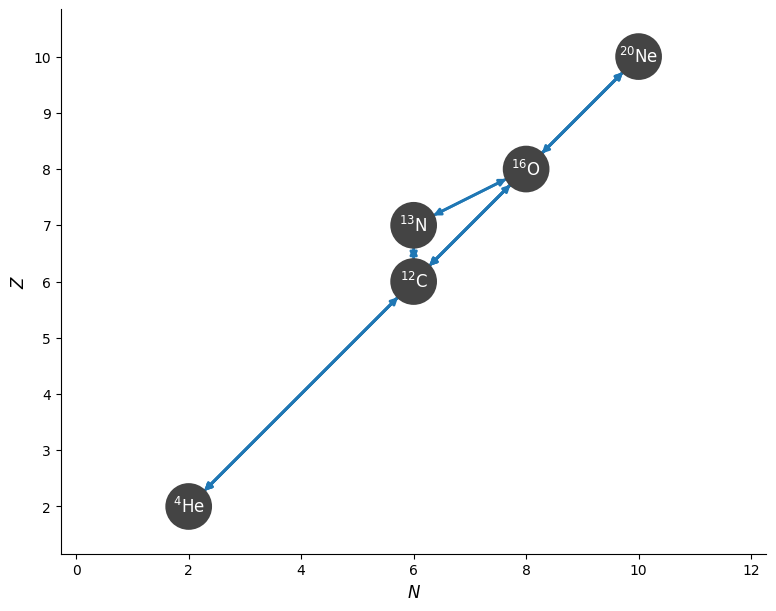

In [3]:
fig = net.plot()

## No temperature evolution

First we'll integrate without evolving the temperature.

In [4]:
rho = 1.e5
T = 2.e8

comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("he4")] = 1
comp.normalize()
Y0 = comp.get_molar_array()

In [5]:
tmax = 1.e7

In [6]:
sol = net.integrate_network(tmax, rho, T, Y0, rtol=1.e-6, atol=1.e-6)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:459: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


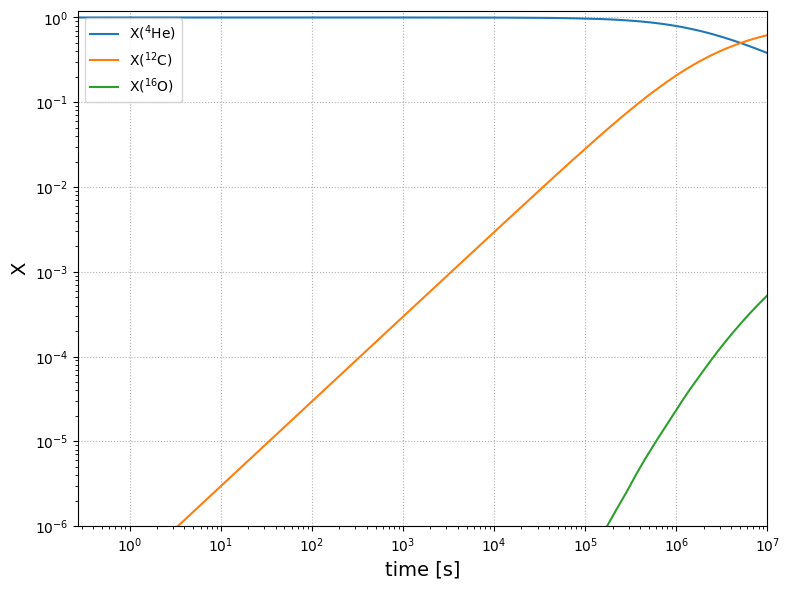

In [7]:
fig = sol.plot_evolution(ymin=1.e-6)

We see it takes about $10^6$ s for the He mass fraction to start to deplete significantly.

## Evolving temperature

When we evolve temperature, we wrap the network's righthand side function that works on molar fractions, $Y$, with one
that includes temperature.  We'll call our vector of unknowns $\xi = ({\bf Y}, T)$.

This wrapper that computes $d\xi/dt$, calling the EOS each evaluation of the righthand side function
to get the updated specific heat.

We enable this integration mode by passing `self_heating=True` to {py:func}`integrate_network <pynucastro.networks.python_network.PythonNetwork.integrate_network>`.

```{note}
Currently, temperature support is not present in the Jacobian, so integration with
`self_heating=True` will use a numerical Jacobian.  Additionally, the wrapper function
is not Numba-compiled.  As a result, integrating with temperature evolution can be slow.
```

In [8]:
sol2 = net.integrate_network(tmax, rho, T, Y0, self_heating=True,
                             rtol=1.e-6, atol=1.e-6)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


Now we can visualize.  First the composition.

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:459: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


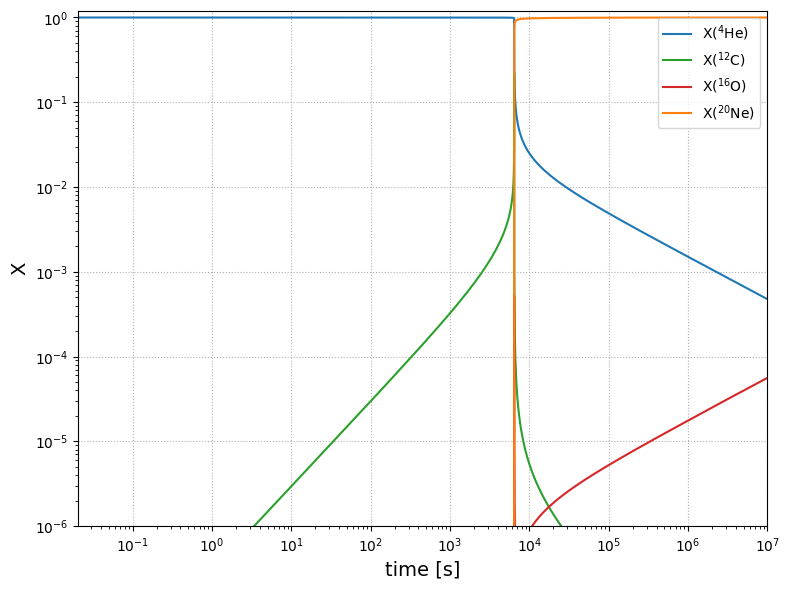

In [9]:
fig = sol2.plot_evolution(ymin=1.e-6)

This looks dramatically different than the fixed-temperature case.  This is not too surprising, since at these temperatures, the 3-$\alpha$ rate is very temperature sensitive, so as the temperature increases due to the energy release from burning, the He burning rate increases dramatically.

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:519: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


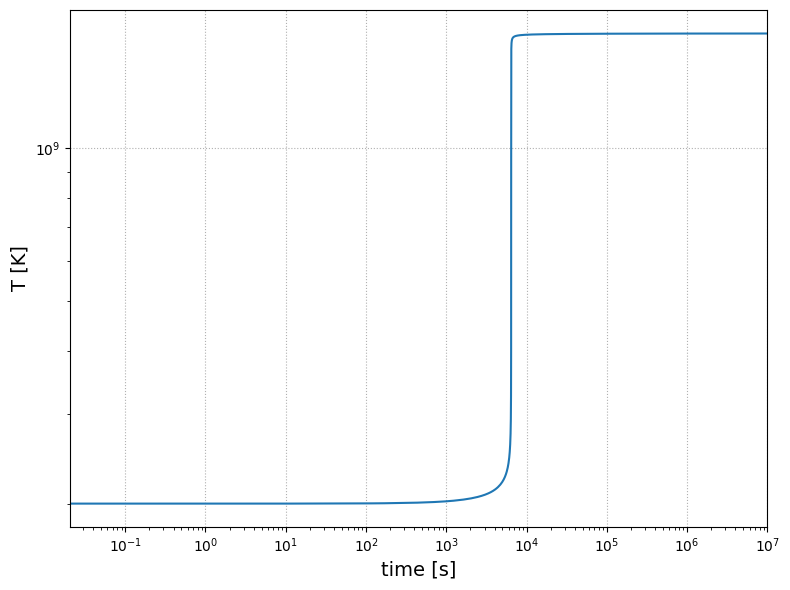

In [10]:
fig = sol2.plot_temperature()

We see that the temperature increased from $2\times 10^8$ K to over $1.6\times 10^9$ K.

```{caution}
In a real star, this energy release would drive a hydrodynamic flow which,
depending on the timescale of the energy release vs. sound waves, could
drive an expansive flow and quench some of this heating.  To really capture this, a full hydrodynamics calculation is needed.
```

```{tip}
It is straightforward to include thermal neutrino loses in the temperature evolution equation as well,
using the {py:meth}`sneut5 <pynucastro.neutrino_cooling.sneut5_mod.sneut5>` method.
```